In [1]:
import os
import sys

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
import joblib

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *
import pwlf
import statsmodels.api as sm



In [2]:
temp_feature = "temperature"
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')

In [3]:
csv_read_path = os.path.join(project_root, "data", "interim", "factors.csv")
df_factors = pd.read_csv(csv_read_path)
df_factors["Date"] = pd.to_datetime(df_factors["Date"])

coefs = {}
grouped = df_factors.groupby(['PowerPlantCode', 'PowerPlantName', "UnitCode"])

for (pp_code, pp_name, unit_code), g in grouped:
    latest_row = g.sort_values("Date", ascending=False).iloc[0]

    coefs[(pp_name, unit_code)] = (latest_row["a1IndexGas"], latest_row["b1IndexGas"])

In [4]:
color_map = {
    1: "purple",
    2: "brown",
    3: "pink",
    4: "gray",
    5: "black",
    6: "red",
    7: "green",
    8: "blue",
    9: "orange"
}

In [5]:
def plot_with_lines(df, x_col, y_col, coefs, name, code, title, save_path=None):
    """رسم نمودار پراکندگی با خطوط رگرسیون و نقاط پیش‌بینی"""

    # نمودار اصلی scatter
    fig = go.Figure()

    for peak_value, color in color_map.items():
        df_subset = df[df["is_good_peak"] == peak_value]
        fig.add_trace(go.Scatter(
            x=df_subset[x_col],
            y=df_subset[y_col],
            mode="markers",
            marker=dict(size=4, color=color),
            name=f"is_good_peak = {peak_value}",
            hovertext=df_subset['datetime']
        ))
    # ظاهر نقاط
    fig.update_traces(
        marker=dict(size=4, sizemode='diameter', sizeref=1, opacity=0.7)
    )

    # filtered6_df = df[(df["is_good_peak"] == 6)&(df[temp_feature] >= 10)&(df[temp_feature] <= 25)]
    # model = pwlf.PiecewiseLinFit(filtered6_df[x_col].values, filtered6_df[y_col].values)
    # res = model.fit(1)
    # model = joblib.load(f"../../filter_data/models/{name}-{code}.joblib")
    filtered_df = df[df["is_good_peak"] == 9]
    if len(filtered_df) > 0:
        X = filtered_df[x_col].values.reshape(-1, 1)
        y = filtered_df[y_col].values

        X = sm.add_constant(X)  # اضافه کردن bias (b)

        model = sm.QuantReg(y, X)
        res = model.fit(q=0.98)

        if model != None:
            x_new = np.arange(0, 50).reshape(-1, 1)

            # حتماً add_constant
            X_new = sm.add_constant(x_new)

            # پیش‌بینی
            y_pred = res.predict(X_new)

            fig.add_trace(go.Scatter(
                x=np.arange(0, 50),
                y=y_pred,
                mode="lines",
                name=f"prediction",
                line=dict(dash="solid", width=2)
            ))

    filtered_df = df[df["is_good_peak"] == 5]

    X = filtered_df[x_col].values.reshape(-1, 1)
    y = filtered_df[y_col].values

    X = sm.add_constant(X)  # اضافه کردن bias (b)

    model = sm.QuantReg(y, X)
    res = model.fit(q=0.98)

    if model != None:
        x_new = np.arange(0, 50).reshape(-1, 1)

        # حتماً add_constant
        X_new = sm.add_constant(x_new)

        # پیش‌بینی
        y_pred = res.predict(X_new)

        fig.add_trace(go.Scatter(
            x=np.arange(0, 50),
            y=y_pred,
            mode="lines",
            name=f"prediction",
            line=dict(dash="solid", width=2)
        ))

    # خطوط رگرسیون
    # for a, b in coefs.get((name, code), []):
    a, b = coefs.get((name, code))
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    y_line = a * x_line + b

    fig.add_trace(go.Scatter(
        x=x_line,
        y=y_line,
        mode="lines",
        name=f"y = {a:.3f}x + {b:.3f}",
        line=dict(dash="dash", width=2)
    ))

    X = filtered_df[x_col].values.reshape(-1, 1)
    y = filtered_df[y_col].values
    model = LinearRegression()
    model.fit(X, y)
    x_new = np.arange(0, 50).reshape(-1, 1)
    y_pred = model.predict(x_new)
    # fig.add_trace(go.Scatter(
    #     x=np.arange(0,50),
    #     y=y_pred,
    #     mode="lines",
    #     name=f"prediction2",
    #     line=dict(dash="solid", width=2)
    # ))

    # ذخیره یا نمایش
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.write_html(save_path)
    else:
        fig.show()


def show(df_m1, save=False, param=None):
    name, code = param['name'], param['code']

    fig = px.scatter(
        df_m1,
        x="datetime",
        y='generation',
        color='is_good_peak',
        title='Generation over Time by Batch Interval',
        labels={'generation': 'Generation', 'datetime': 'Time'},
        hover_data=['datetime', 'generation', temp_feature]
    )

    if save:
        path = f"{project_root}/src/visualization/unit_figs/new_new_filter6/{name}-{code}_l.html"
        os.makedirs(os.path.dirname(path), exist_ok=True)
        fig.write_html(path)
    else:
        fig.show()

    # # نمودار ۲: generation vs temperature
    save_path = (f"{project_root}/src/visualization/unit_figs/new_new_filter6/{name}-{code}_s.html"
                 if save else None)
    plot_with_lines(
        df_m1, temp_feature, 'generation', coefs, name, code,
        title='Generation vs Temperature', save_path=save_path
    )




In [122]:
power_plants = df[['name', 'code']].drop_duplicates()

for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=2))
    df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
    try:
        show(df_n_c_plot, save=True, param={"name": name_plot, "code": code_plot})
    except Exception as e:
        print(e)
        print(name_plot, code_plot)

zero-size array to reduction operation maximum which has no identity
سیکل ترکیبی یزد G13


U:\ML_project\Bargh_ML\venv\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning:

Maximum number of iterations (1000) reached.



In [159]:
def plot_callback(t_grid, density, points):
    import matplotlib.pyplot as plt
    
    # چاپ مقادیر نقاط
    if points:
        left, left_1, right, right_1, valley_idx = points
        print(f"left peak: {t_grid[left]:.3f}")
        print(f"temp_min idx: {t_grid[left_1]:.3f}")
        print(f"right peak: {t_grid[right]:.3f}")
        print(f"temp_max idx: {t_grid[right_1]:.3f}")
        print(f"valley: {t_grid[valley_idx]:.3f}")
    
    # رسم KDE
    plt.plot(t_grid, density, label='KDE')
    
    # رسم خطوط عمودی نقاط
    if points:
        plt.axvline(t_grid[left], color='red', linestyle='--', label='left peak')
        plt.axvline(t_grid[left_1], color='orange', linestyle='--', label='temp_min idx')
        plt.axvline(t_grid[right], color='green', linestyle='--', label='right peak')
        plt.axvline(t_grid[right_1], color='purple', linestyle='--', label='temp_max idx')
        plt.axvline(t_grid[valley_idx], color='black', linestyle='-', label='valley')
    
    plt.legend()
    plt.show()


In [164]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks


def find_valley_on_projection(t, temp_min=-1000, temp_max=1000):
    """
    Given 1D projection t, find the lowest density valley between two main peaks
    """
    kde = gaussian_kde(t)
    t_grid = np.linspace(t.min(), t.max(), 500)
    left_1 = np.searchsorted(t_grid, temp_min, side='left')
    right_1 = np.searchsorted(t_grid, temp_max, side='left')
    
    density = kde(t_grid)
    peaks, _ = find_peaks(density)
    if len(peaks) < 2:
        return None, None
    
    # two highest peaks
    peaks = peaks[np.argsort(density[peaks])[-2:]]
    left_0, right_0 = np.sort(peaks)
    print(left_0,left_1,"---",right_0,right_1)
    if right_1 <= left_0:
        valley_idx = right_1
    elif left_1 >= right_0 :
        valley_idx = left_1
    else:
        left = max(left_0, left_1)
        right = min(right_0, right_1)
        valley_idx = left + np.argmin(density[left:right])
        
    plot_callback(t_grid, density, (left_0, left_1, right_0, right_1, valley_idx))
    return t_grid[valley_idx], density[valley_idx]


def find_best_gap_line(x, y, angle_range=(-np.pi / 2 * (45 / 90), -np.pi / 2 * (25 / 90)), n_angles=20):
    """
    Finds the line y = a*x + b passing through the lowest-density linear gap
    """

    best_score = np.inf
    best_params = None

    angles = np.linspace(angle_range[0], angle_range[1], n_angles)

    for theta in angles:
        # slope
        print(theta)
        a = np.tan(theta)

        # normal projection
        t = (a * x - y) / np.sqrt(a * a + 1)

        t0, density_min = find_valley_on_projection(t)
        if t0 is None:
            continue

        # lower density = better gap
        if density_min < best_score:
            best_score = density_min
            b = -t0 * np.sqrt(a * a + 1)
            best_params = (a, b)

    return best_params


def find_best_gap_line_given_a(x, y, a, p_min, p_max, delta, interval):
    """
    Finds the line y = a*x + b passing through the lowest-density linear gap
    """

    # normal projection
    t = (y - a * x) / np.sqrt(a * a + 1)
    temp_min = get_b_c(x, y, a, p_min, interval) / np.sqrt(a * a + 1)
    temp_max = (get_b_c(x, y, a, p_max, interval) + delta) / np.sqrt(a * a + 1)
    t0, density_min = find_valley_on_projection(t, temp_min, temp_max)
    if t0 is None:
        return None
    
    b = t0 * np.sqrt(a * a + 1)
    print(b,":",get_b_c(x, y, a, p_min, interval),(get_b_c(x, y, a, p_max, interval) + delta))
    best_params = (a, b)

    return best_params


def get_b_c(x, y, a, p, interval = (0,25)):
    mask = (interval[0] <= x) & (x <= interval[1])
    x = x[mask]
    y = y[mask]

    r = y - a * x
    b_c = np.quantile(r, p)
    return b_c


def plot_result(x, y, a, b):
    plt.scatter(x, y, s=5, alpha=0.6)

    xx = np.linspace(x.min(), x.max(), 300)
    yy = a * xx + b
    plt.plot(xx, yy, 'r', linewidth=2)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Unsupervised Maximum Gap Line")
    plt.grid()


def plot_result_lines(x, y, a_s, b_s):
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, s=5, alpha=0.6, color='gray')

    xx = np.linspace(x.min(), x.max(), 300)

    cmap = plt.cm.tab10  # colormap با رنگ‌های متمایز
    n = len(a_s)

    for i, (a, b) in enumerate(zip(a_s, b_s)):
        yy = a * xx + b
        plt.plot(xx, yy, color=cmap(i % cmap.N), linewidth=2, label=f'line {i} {a:0.2f} {b:0.2f}')

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Unsupervised Maximum Gap Lines")
    plt.grid()
    plt.legend()
    plt.show()

In [165]:
coefs_jas = {
    ('سیکل ترکیبی شیروان', 'G11'): (-0.88622, 138.71087, 21),
    ('سیکل ترکیبی شیروان', 'G12'): (-0.78622, 138.71087, 5),  # Good
    ('سیکل ترکیبی شیروان', 'G13'): (-0.78622, 138.71087, 5),
    ('سیکل ترکیبی شیروان', 'G14'): (-0.78622, 138.71087, 3),  # Good
    ('سیکل ترکیبی شیروان', 'G15'): (-0.78622, 138.71087, 0),  # Good
    ('سیکل ترکیبی شیروان', 'G16'): (-0.78622, 138.71087, 6),

    ('سیکل ترکیبی یزد', 'G14'): (-0.653, 112.4, 1),  # Good
    ('سیکل ترکیبی یزد', 'G15'): (-0.77, 136.24, 16),
    ('سیکل ترکیبی یزد', 'G16'): (-0.77, 136.24, 3),  # Good

    ('قم', 'G11'): (-0.689, 117.4, 3),  # Good
    ('قم', 'G12'): (-0.689, 117.4, 3),  # Good
    ('قم', 'G13'): (-0.689, 117.4, 4),  # Good
    ('قم', 'G14'): (-0.689, 117.4, 4),  # Good

    ('شهدای پاکدشت - دماوند', 'G11'): (-0.83, 144.34, 3),  # Good
    ('شهدای پاکدشت - دماوند', 'G12'): (-0.83, 144.34, 3),
    ('شهدای پاکدشت - دماوند', 'G13'): (-0.83, 144.34, 1),  # Good
    ('شهدای پاکدشت - دماوند', 'G14'): (-0.83, 144.34, 2),
    ('شهدای پاکدشت - دماوند', 'G15'): (-0.83, 144.34, 3),  # Good
    ('شهدای پاکدشت - دماوند', 'G16'): (-0.83, 144.34, 3),  # Good
    ('شهدای پاکدشت - دماوند', 'G17'): (-0.83, 144.34, 3),  # Good
    ('شهدای پاکدشت - دماوند', 'G18'): (-0.83, 144.34, 3),  # Good
    ('شهدای پاکدشت - دماوند', 'G19'): (-0.83, 144.34, 3),  # Good
    ('شهدای پاکدشت - دماوند', 'G20'): (-0.83, 144.34, 7),  # Good
    ('شهدای پاکدشت - دماوند', 'G21'): (-0.825, 149.3, -3),  # Good
    ('شهدای پاکدشت - دماوند', 'G22'): (-0.825, 149.3, 3),  # Good
}


In [166]:
name_plot = "سیکل ترکیبی شیروان"
code_plot = "G11"
'''
شهدای پاکدشت - دماوند G16
شهدای پاکدشت - دماوند G18
شهدای پاکدشت - دماوند G21'''

'\nشهدای پاکدشت - دماوند G16\nشهدای پاکدشت - دماوند G18\nشهدای پاکدشت - دماوند G21'

جنوب اصفهان - چهلستون G11
جنوب اصفهان - چهلستون G12
جنوب اصفهان - چهلستون G13
جنوب اصفهان - چهلستون G14
جنوب اصفهان - چهلستون G15
جنوب اصفهان - چهلستون G16
حافظ G11
حافظ G12
حافظ G13
حافظ G14
حافظ G15
حافظ G16
سبلان G11
سبلان G12
سبلان G13
سبلان G14
سبلان G15
سبلان G16
سیکل ترکیبی ارومیه G11
سیکل ترکیبی ارومیه G12
سیکل ترکیبی ارومیه G13
سیکل ترکیبی ارومیه G14
سیکل ترکیبی ارومیه G15
سیکل ترکیبی ارومیه G16
سیکل ترکیبی شیروان G11
278 348 --- 349 430
left peak: 111.918
temp_min idx: 118.183
right peak: 118.273
temp_max idx: 125.523
valley: 118.183


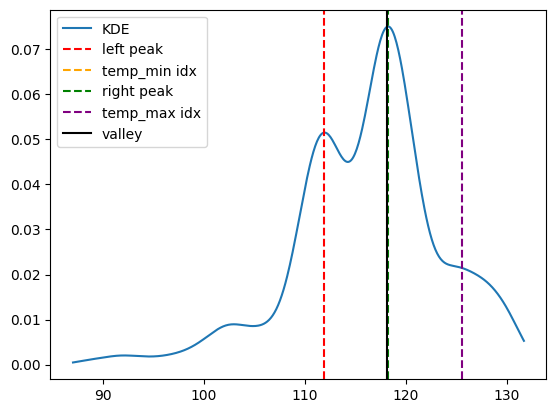

150.3362671749773 : 150.28400111 159.5921823279


<Figure size 600x500 with 0 Axes>

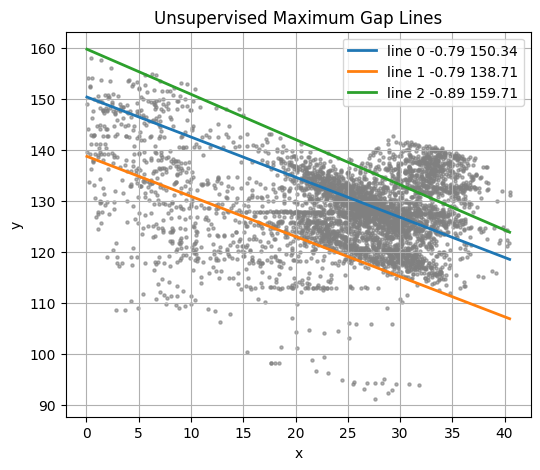

a = -0.786, b = 150.336
سیکل ترکیبی شیروان G12
277 271 --- 352 366
left peak: 110.352
temp_min idx: 109.838
right peak: 116.767
temp_max idx: 117.964
valley: 113.859


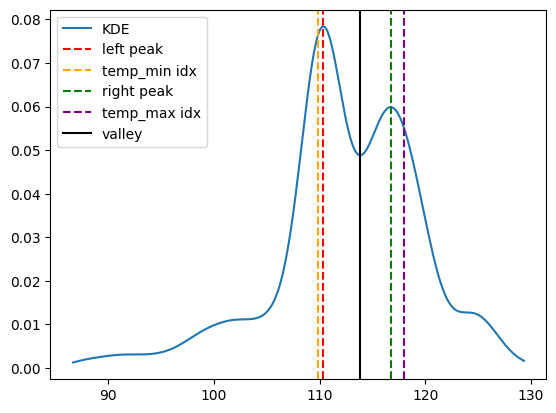

144.83516111058114 : 139.67257562000003 150.05797419243999


<Figure size 600x500 with 0 Axes>

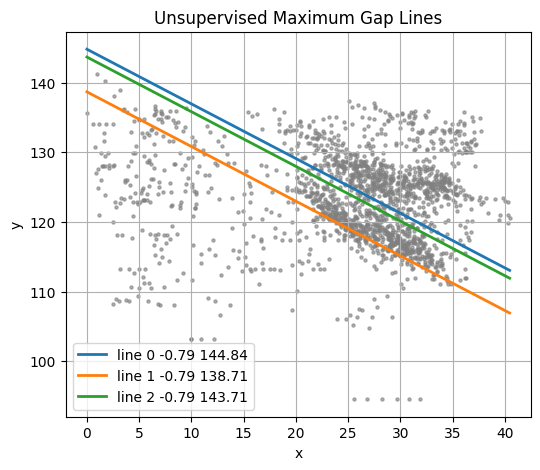

a = -0.786, b = 144.835
سیکل ترکیبی شیروان G13
318 280 --- 448 339
left peak: 112.318
temp_min idx: 109.630
right peak: 121.515
temp_max idx: 113.804
valley: 113.733


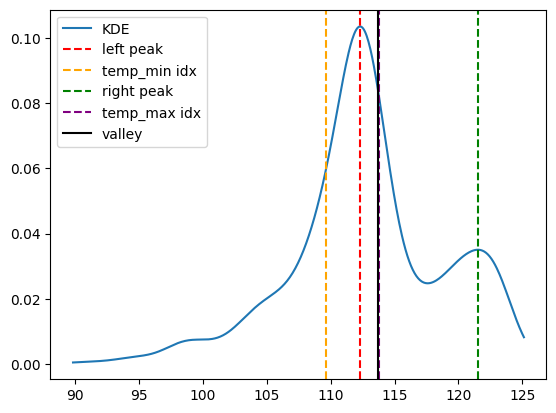

144.67568936663912 : 139.42308809420481 144.7653841878622


<Figure size 600x500 with 0 Axes>

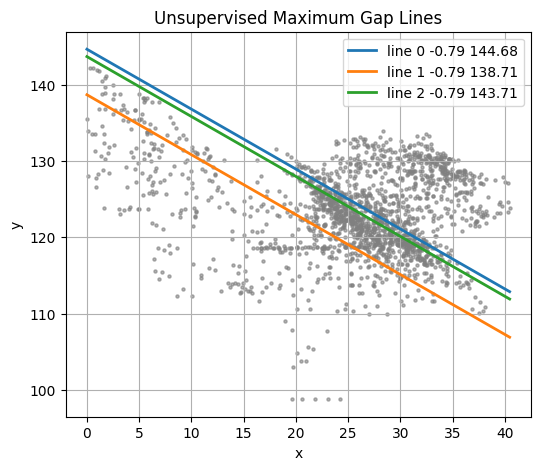

a = -0.786, b = 144.676
سیکل ترکیبی شیروان G14
317 304 --- 446 370
left peak: 109.363
temp_min idx: 108.567
right peak: 117.259
temp_max idx: 112.607
valley: 112.546


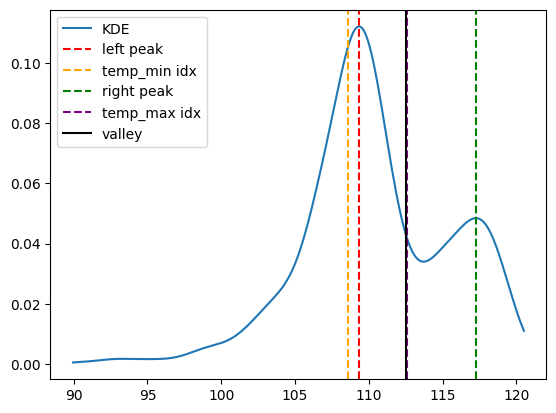

143.16507092752397 : 138.07093982 143.193099848976


<Figure size 600x500 with 0 Axes>

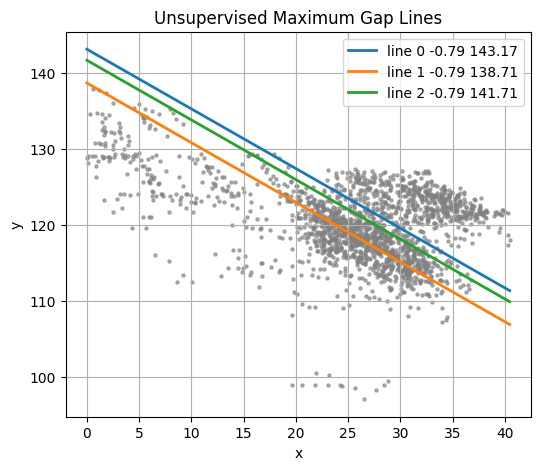

a = -0.786, b = 143.165
سیکل ترکیبی شیروان G15
286 293 --- 363 408
left peak: 106.521
temp_min idx: 106.997
right peak: 111.764
temp_max idx: 114.829
valley: 108.632


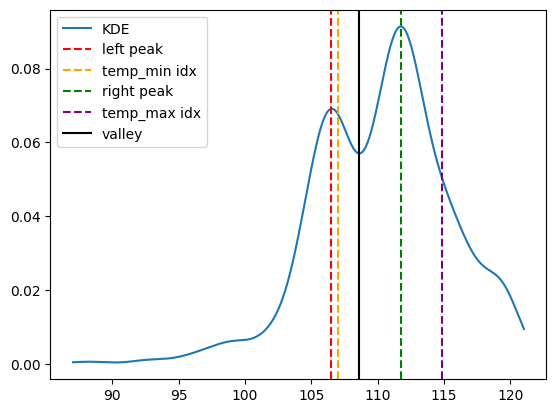

138.18629788212425 : 136.10689822 146.0627215686928


<Figure size 600x500 with 0 Axes>

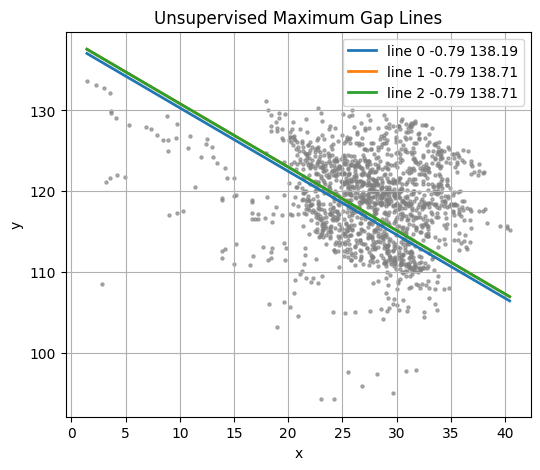

a = -0.786, b = 138.186
سیکل ترکیبی شیروان G16
324 312 --- 427 369
left peak: 111.212
temp_min idx: 110.319
right peak: 118.878
temp_max idx: 114.561
valley: 114.487


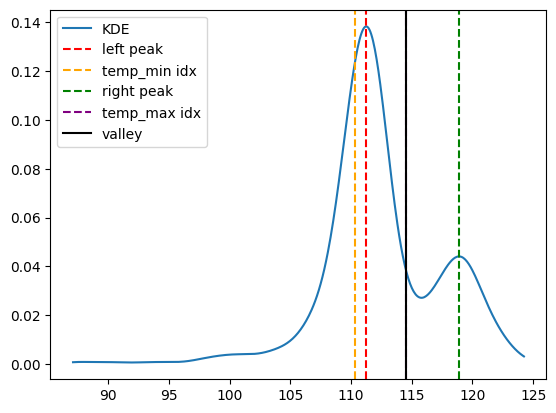

145.63438581942614 : 140.269833377244 145.6883692431808


<Figure size 600x500 with 0 Axes>

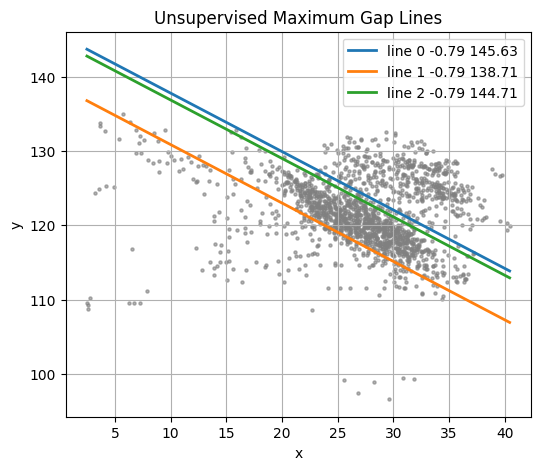

a = -0.786, b = 145.634
سیکل ترکیبی یزد G11
سیکل ترکیبی یزد G12
سیکل ترکیبی یزد G13
سیکل ترکیبی یزد G14
99 101 --- 374 147
left peak: 93.159
temp_min idx: 93.207
right peak: 99.735
temp_max idx: 94.307
valley: 94.283


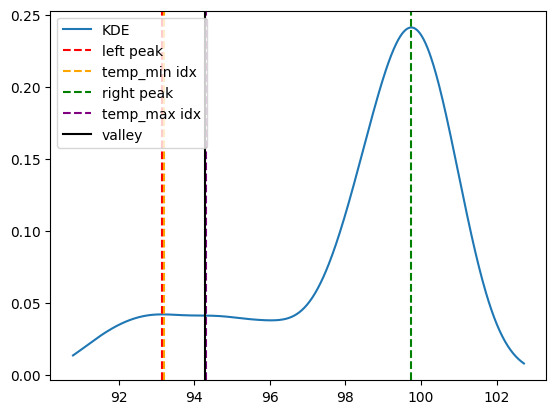

112.60477903807616 : 111.31402 112.63115563713001


<Figure size 600x500 with 0 Axes>

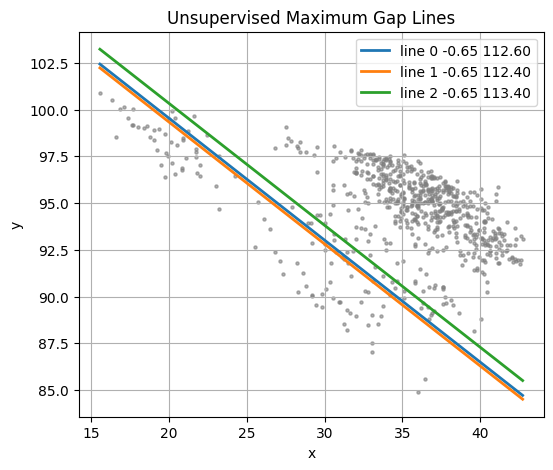

a = -0.653, b = 112.605
سیکل ترکیبی یزد G15
Error: *****************
index -1 is out of bounds for axis 0 with size 0
سیکل ترکیبی یزد G16
245 266 --- 433 331
left peak: 105.906
temp_min idx: 107.144
right peak: 116.990
temp_max idx: 110.976
valley: 109.856


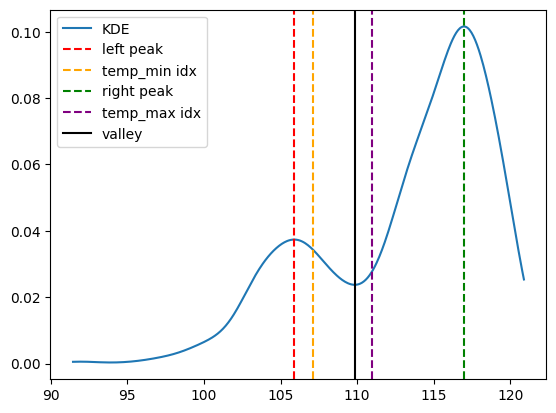

138.6491665677054 : 135.16946832300002 140.02297912


<Figure size 600x500 with 0 Axes>

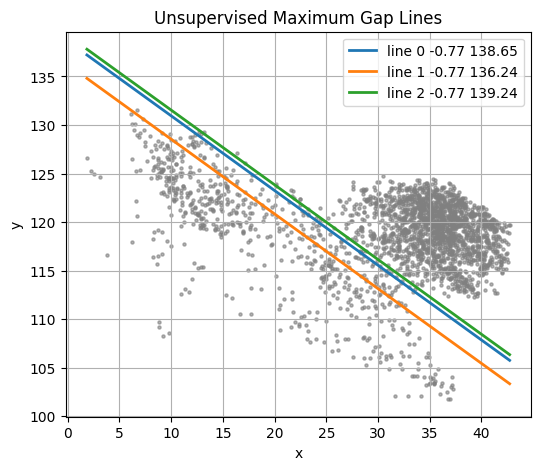

a = -0.770, b = 138.649
شهدای پاکدشت - دماوند G11
288 279 --- 427 354
left peak: 108.329
temp_min idx: 107.696
right peak: 118.110
temp_max idx: 112.973
valley: 112.129


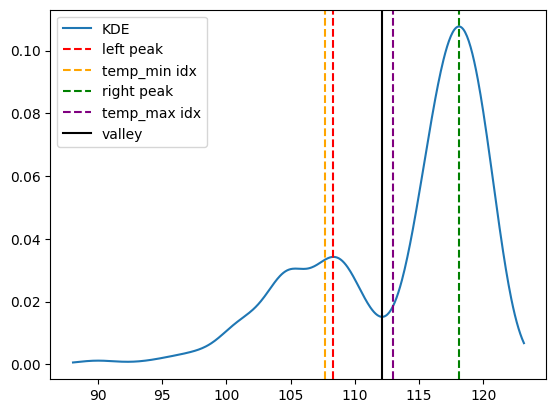

145.7199285270541 : 139.9362791992 146.75594523999996


<Figure size 600x500 with 0 Axes>

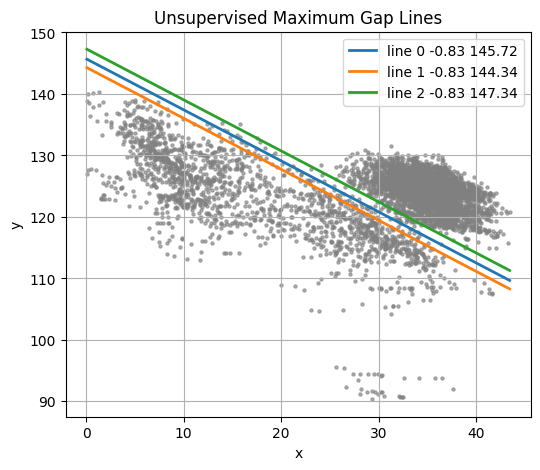

a = -0.830, b = 145.720
شهدای پاکدشت - دماوند G12
298 251 --- 443 364
left peak: 109.352
temp_min idx: 105.835
right peak: 120.202
temp_max idx: 114.291
valley: 113.393


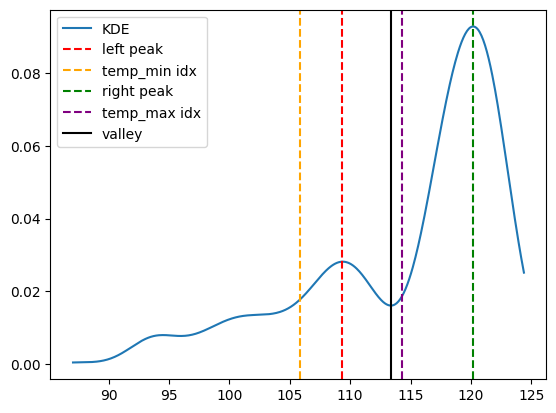

147.36275980961923 : 137.52083466 148.457169894


<Figure size 600x500 with 0 Axes>

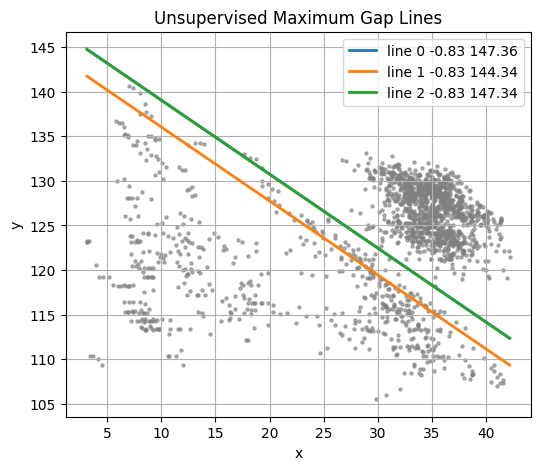

a = -0.830, b = 147.363
شهدای پاکدشت - دماوند G13
228 226 --- 441 291
left peak: 107.762
temp_min idx: 107.632
right peak: 121.668
temp_max idx: 111.875
valley: 111.810


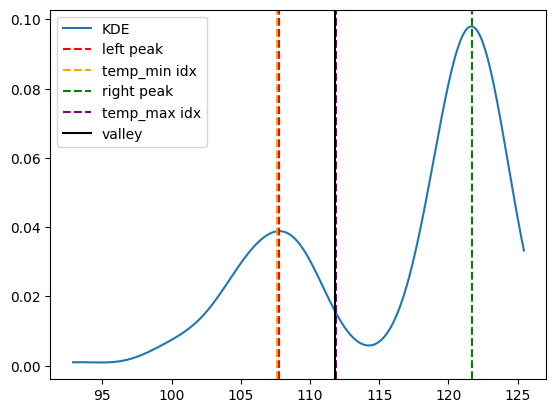

145.30532939785573 : 139.8748213502 145.34860576


<Figure size 600x500 with 0 Axes>

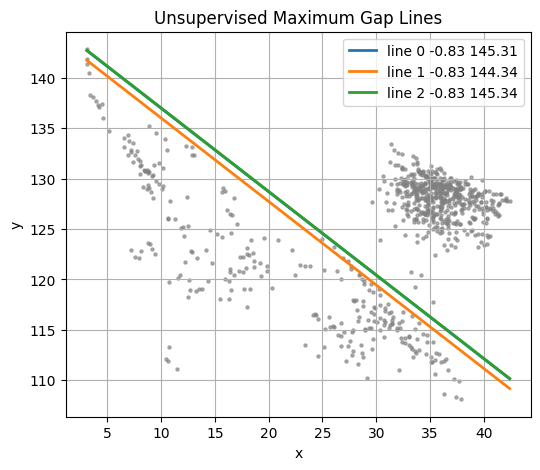

a = -0.830, b = 145.305
شهدای پاکدشت - دماوند G14
266 252 --- 425 302
left peak: 107.503
temp_min idx: 106.456
right peak: 119.394
temp_max idx: 110.195
valley: 110.121


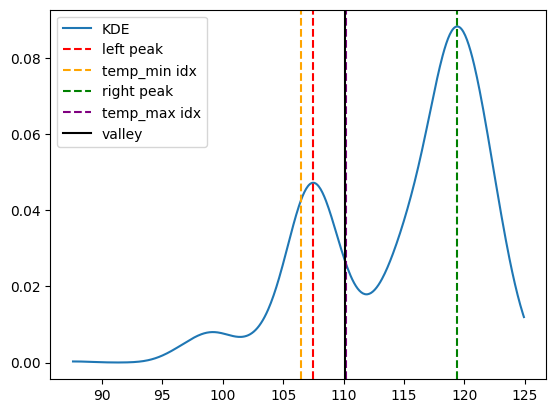

143.11029133667336 : 138.3366666 143.1294538178


<Figure size 600x500 with 0 Axes>

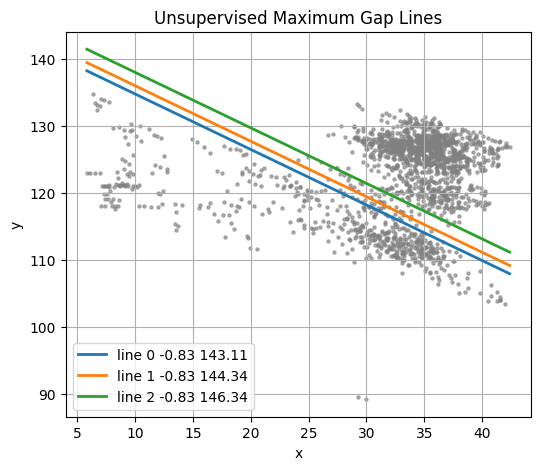

a = -0.830, b = 143.110
شهدای پاکدشت - دماوند G15
327 284 --- 451 376
left peak: 110.299
temp_min idx: 107.339
right peak: 118.836
temp_max idx: 113.673
valley: 112.915


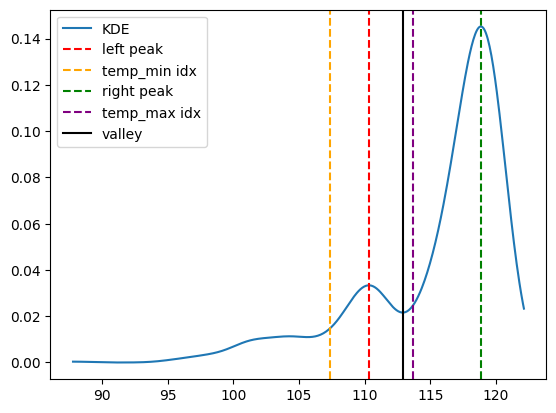

146.7421757855711 : 139.49501275100002 147.66285964699998


<Figure size 600x500 with 0 Axes>

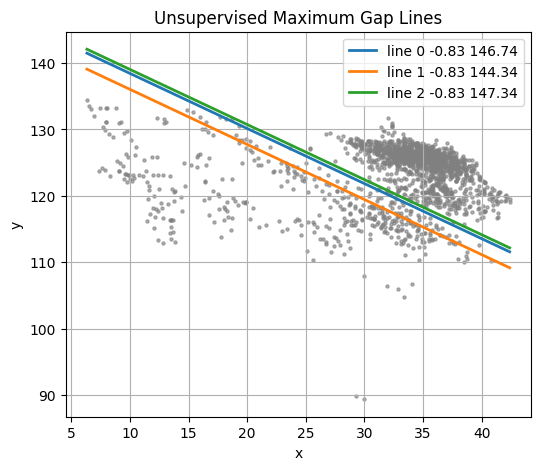

a = -0.830, b = 146.742
شهدای پاکدشت - دماوند G16
325 283 --- 445 357
left peak: 108.963
temp_min idx: 106.114
right peak: 117.105
temp_max idx: 111.134
valley: 111.067


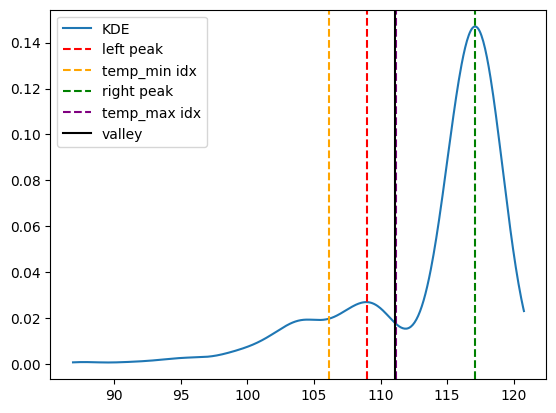

144.33960801803607 : 137.8853674 144.41138984


<Figure size 600x500 with 0 Axes>

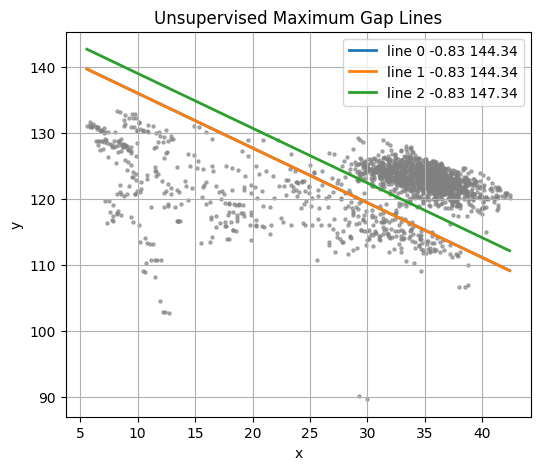

a = -0.830, b = 144.340
شهدای پاکدشت - دماوند G17
186 184 --- 410 291
left peak: 107.655
temp_min idx: 107.551
right peak: 119.273
temp_max idx: 113.101
valley: 113.049


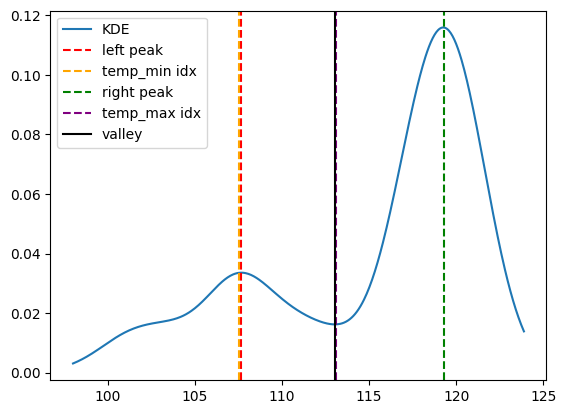

146.9158055799599 : 139.70548140000002 146.9825648966


<Figure size 600x500 with 0 Axes>

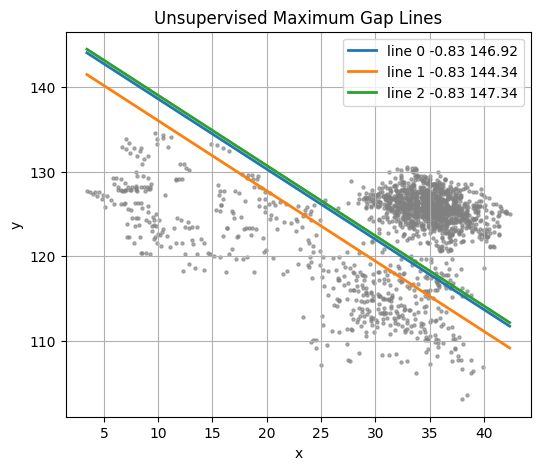

a = -0.830, b = 146.916
شهدای پاکدشت - دماوند G18
291 253 --- 442 326
left peak: 107.902
temp_min idx: 105.142
right peak: 118.870
temp_max idx: 110.444
valley: 110.371


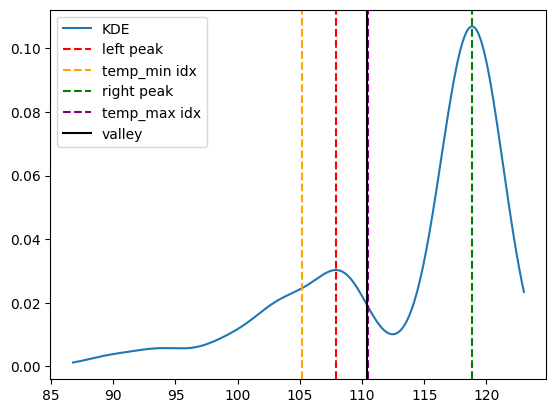

143.43607913226452 : 136.5461386 143.5219000541


<Figure size 600x500 with 0 Axes>

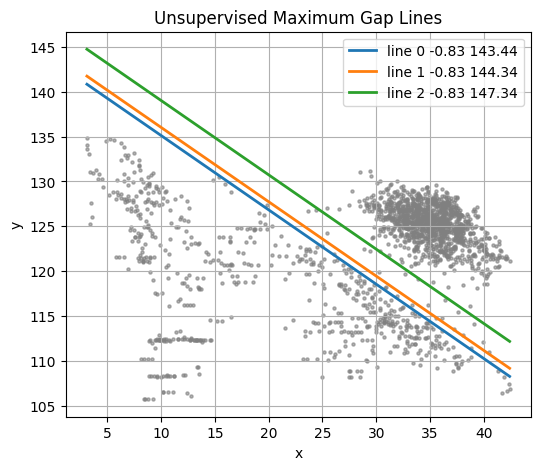

a = -0.830, b = 143.436
شهدای پاکدشت - دماوند G19
234 233 --- 412 294
left peak: 107.415
temp_min idx: 107.352
right peak: 118.540
temp_max idx: 111.165
valley: 111.102


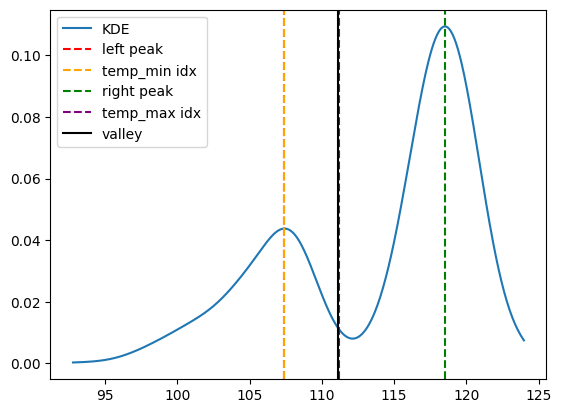

144.38574914104208 : 139.4414566 144.3908966


<Figure size 600x500 with 0 Axes>

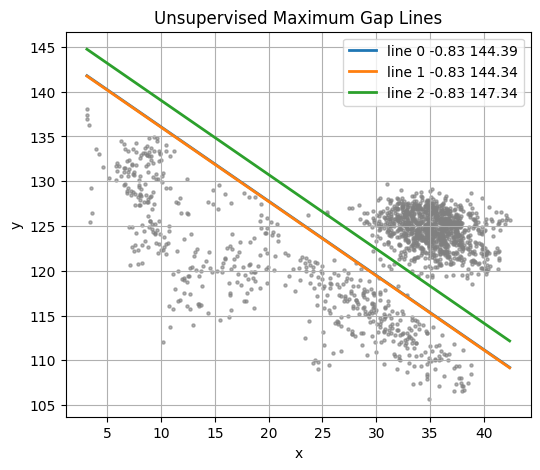

a = -0.830, b = 144.386
شهدای پاکدشت - دماوند G20
293 243 --- 431 343
left peak: 110.876
temp_min idx: 106.955
right peak: 121.700
temp_max idx: 114.798
valley: 114.719


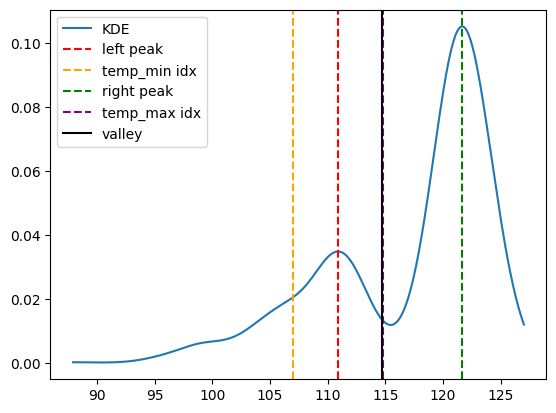

149.0866034134469 : 138.95083939999998 149.12863698419997


<Figure size 600x500 with 0 Axes>

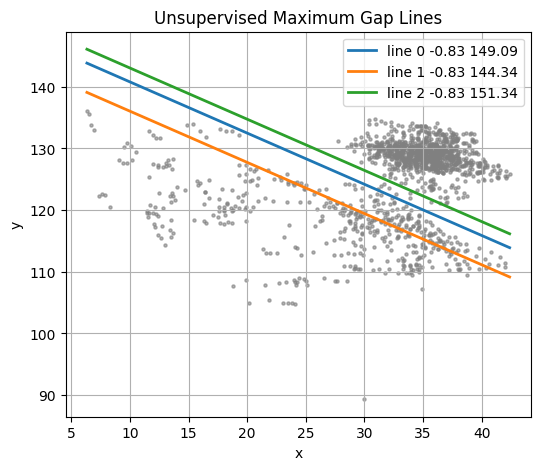

a = -0.830, b = 149.087
شهدای پاکدشت - دماوند G21
270 226 --- 405 347
left peak: 107.404
temp_min idx: 104.210
right peak: 117.205
temp_max idx: 112.994
valley: 111.833


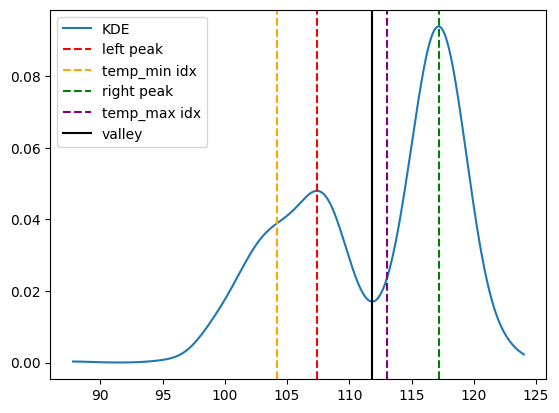

144.97887321342682 : 135.0112929 146.468461246


<Figure size 600x500 with 0 Axes>

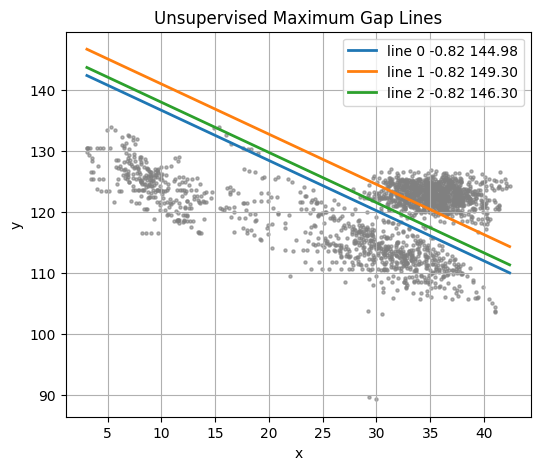

a = -0.825, b = 144.979
شهدای پاکدشت - دماوند G22
Error: *****************
index -1 is out of bounds for axis 0 with size 0
شهدای پیروز - بهبهان G11
شهدای پیروز - بهبهان G12
عسلویه G11
عسلویه G12
عسلویه G13
عسلویه G14
عسلویه G15
عسلویه G16
قم G11
142 189 --- 375 280
left peak: 95.251
temp_min idx: 96.861
right peak: 103.237
temp_max idx: 99.980
valley: 98.095


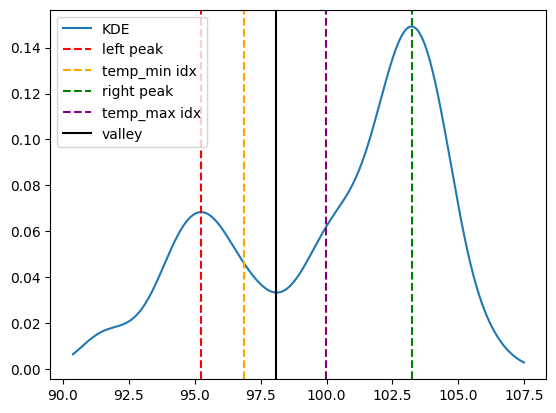

119.12513119238476 : 117.6190592268 121.39489350258


<Figure size 600x500 with 0 Axes>

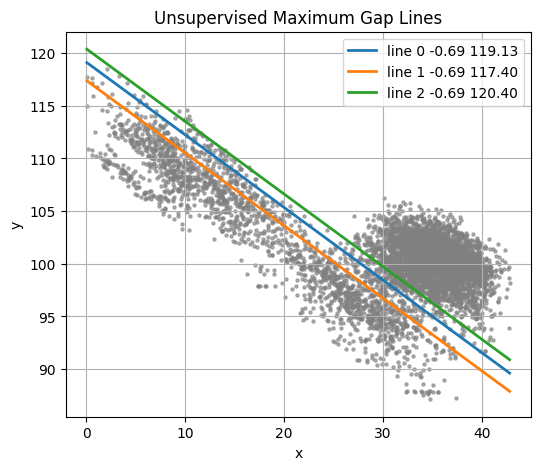

a = -0.689, b = 119.125
قم G12
202 229 --- 412 302
left peak: 97.454
temp_min idx: 98.351
right peak: 104.434
temp_max idx: 100.778
valley: 99.348


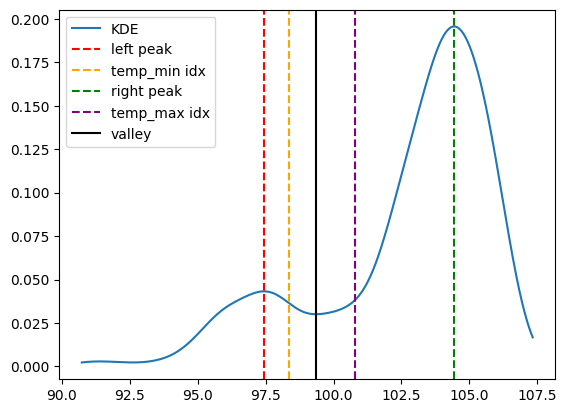

120.646893749499 : 119.41373180000001 122.3521932


<Figure size 600x500 with 0 Axes>

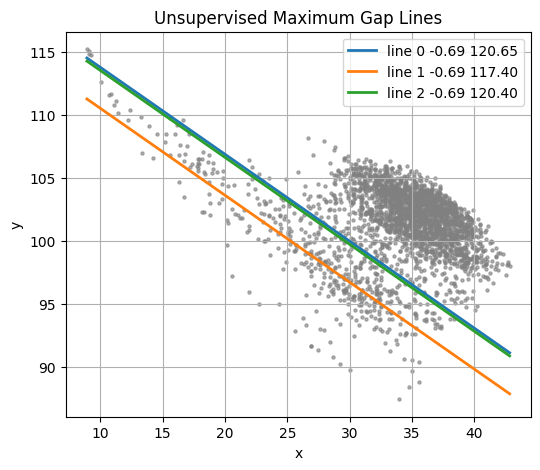

a = -0.689, b = 120.647
قم G13
168 181 --- 392 278
left peak: 96.281
temp_min idx: 96.730
right peak: 104.006
temp_max idx: 100.075
valley: 99.385


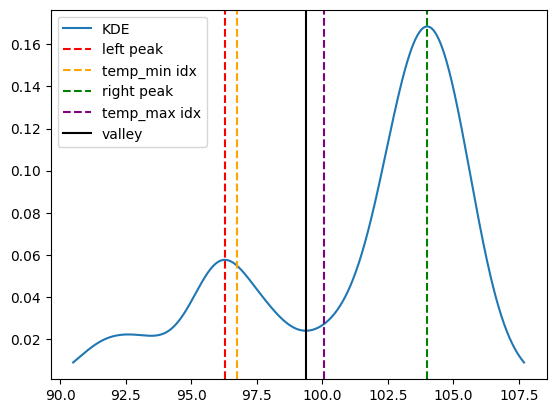

120.69142917377555 : 117.46324299999999 121.51970732775


<Figure size 600x500 with 0 Axes>

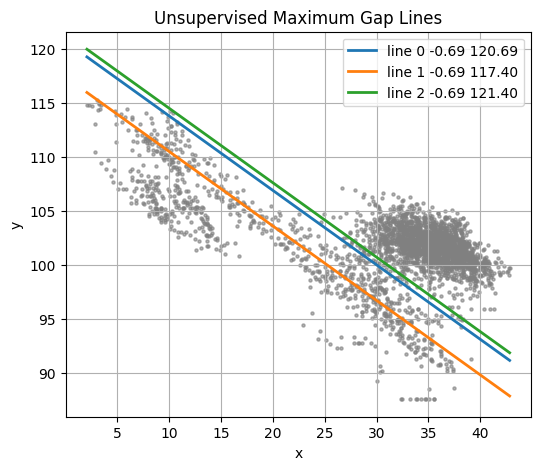

a = -0.689, b = 120.691
قم G14
190 202 --- 348 306
left peak: 96.801
temp_min idx: 97.200
right peak: 102.059
temp_max idx: 100.661
valley: 98.465


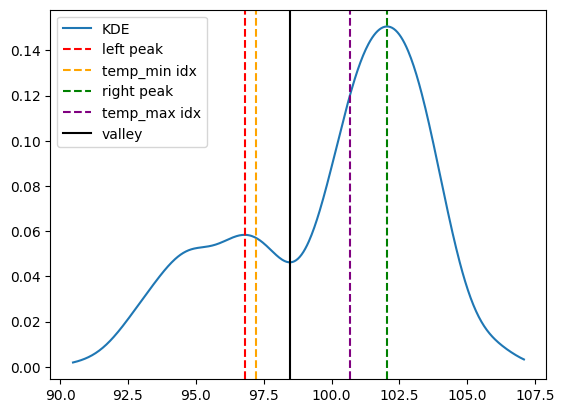

119.5735212301042 : 118.00047168900001 122.2016776488


<Figure size 600x500 with 0 Axes>

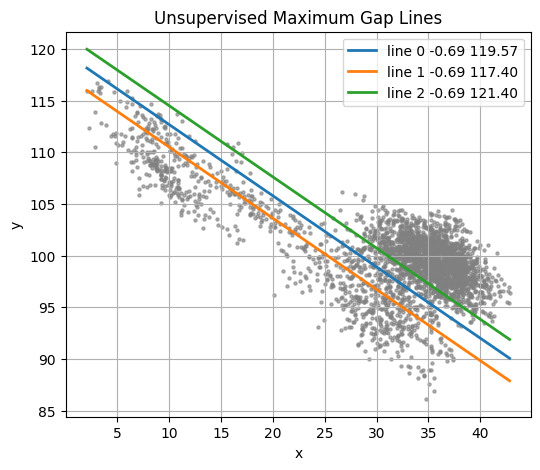

a = -0.689, b = 119.574
پرند G11
پرند G12
پرند G13
پرند G14
پرند G15
پرند G16
گیلان G11
گیلان G12
گیلان G13
گیلان G14
گیلان G15
گیلان G16


In [183]:
name_plot = "شهدای پاکدشت - دماوند"
code_plot = "G16"
power_plants = df[['name', 'code']].drop_duplicates()


for row in power_plants.itertuples():
    try:
        name_plot, code_plot = row.name, row.code
        print(name_plot,code_plot)
        jas_coef = coefs_jas.get((name_plot, code_plot))
        if jas_coef:
            jas_a = jas_coef[0]
            jas_b = jas_coef[1] + jas_coef[2]
            
        else:
            continue
            
        ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=5))
        df_n_c = ds_n_c_plot.filter_name_code(name_plot, code_plot)
        X = df_n_c[temp_feature].values
        y = df_n_c["generation"].values
        mask = (X > 0) & ((y - (X * (-0.7) + 140)) > -30)
        p_min = 0.8
        p_max = 0.99
        delta = 1
        X = X[mask]
        y = y[mask]
        interval = (0,20)
        a_u = coefs[(name_plot, code_plot)][0]
        a, b = find_best_gap_line_given_a(X, y, a_u, p_min, p_max, delta, interval)
        plt.figure(figsize=(6, 5))
        
        a_s = [a, coefs[(name_plot, code_plot)][0]]
        b_s = [b, coefs[(name_plot, code_plot)][1]]
        if jas_coef:
            a_s.append(jas_a)
            b_s.append(jas_b)
        plot_result_lines(X, y, a_s, b_s)
        plt.show()
        print(f"a = {a:.3f}, b = {b:.3f}")
    except Exception as e:
        print("Error: *****************")
        print(e)

In [6]:
df

,id,name,code,date,hour,load_level,forecasted_load,required,declared,status,...,snow,surface_pressure,evapotranspiration,wind_speed,wind_direction,datetime,season,day_of_week,month,is_good_peak
0,406,جنوب اصفهان - چهلستون,G11,2021-03-23,4,L,27368,0.000,123.0,SO,...,NaN,825.06024,0.0,6.924738,207.89717,2021-03-23 04:00:00,spring,1,3,1
1,406,جنوب اصفهان - چهلستون,G11,2021-03-23,5,L,27225,107.699,123.0,SO,...,0.0,825.17780,0.0,6.877789,222.87889,2021-03-23 05:00:00,spring,1,3,1
2,406,جنوب اصفهان - چهلستون,G11,2021-03-23,6,L,27095,107.699,123.0,SO,...,0.0,826.00476,0.0,6.618519,224.99990,2021-03-23 06:00:00,spring,1,3,1
3,406,جنوب اصفهان - چهلستون,G11,2021-03-23,7,L,26987,120.324,123.0,SO,...,0.0,825.96423,0.0,8.707237,209.74480,2021-03-23 07:00:00,spring,1,3,1
4,406,جنوب اصفهان - چهلستون,G11,2021-03-23,8,L,26274,56.696,122.0,SO,...,0.0,827.20764,0.0,7.100310,210.46547,2021-03-23 08:00:00,spring,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1157887,232,گیلان,G16,2022-08-22,20,M,54487,119.800,119.8,SO,...,0.0,1008.87790,0.0,5.991594,327.26477,2022-08-22 20:00:00,summer,0,8,2
1157888,232,گیلان,G16,2022-08-22,21,M,57021,121.600,121.6,SO,...,0.0,1009.56520,0.0,4.024922,280.30478,2022-08-22 21:00:00,summer,0,8,2
1157889,232,گیلان,G16,2022-08-22,22,M,57718,122.900,122.9,SO,...,0.0,1009.66113,0.0,5.804825,240.25520,2022-08-22 22:00:00,summer,0,8,2
1157890,232,گیلان,G16,2022-08-22,23,M,56731,122.900,122.9,SO,...,0.0,1009.65980,0.0,7.127636,224.99990,2022-08-22 23:00:00,summer,0,8,2


In [8]:
coefs

{('پرند', 'G11'): (np.float64(-0.9717), np.float64(162.0)),
 ('پرند', 'G12'): (np.float64(-0.9717), np.float64(162.0)),
 ('پرند', 'G13'): (np.float64(-1.0129), np.float64(168.8)),
 ('پرند', 'G14'): (np.float64(-1.0129), np.float64(168.8)),
 ('پرند', 'G15'): (np.float64(-1.0129), np.float64(168.8)),
 ('پرند', 'G16'): (np.float64(-1.0129), np.float64(168.8)),
 ('شهدای پاکدشت - دماوند', 'G11'): (np.float64(-0.83), np.float64(144.34)),
 ('شهدای پاکدشت - دماوند', 'G12'): (np.float64(-0.83), np.float64(144.34)),
 ('شهدای پاکدشت - دماوند', 'G13'): (np.float64(-0.83), np.float64(144.34)),
 ('شهدای پاکدشت - دماوند', 'G14'): (np.float64(-0.83), np.float64(144.34)),
 ('شهدای پاکدشت - دماوند', 'G15'): (np.float64(-0.83), np.float64(144.34)),
 ('شهدای پاکدشت - دماوند', 'G16'): (np.float64(-0.83), np.float64(144.34)),
 ('شهدای پاکدشت - دماوند', 'G17'): (np.float64(-0.83), np.float64(144.34)),
 ('شهدای پاکدشت - دماوند', 'G18'): (np.float64(-0.83), np.float64(144.34)),
 ('شهدای پاکدشت - دماوند', 'G19'

In [18]:
t_grid = np.array([1, 3, 5, 7, 9])
temp_c = -1

left_1 = np.searchsorted(t_grid, temp_c, side='left')
print(left_1)


0
